#Install Libraries

In [1]:
!pip install rasterio opencv-python scikit-image

#Import Libraries

In [2]:
import rasterio
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

from google.colab import files


#Upload Images

In [3]:
uploaded = files.upload()

before_path = "before.tiff"
after_path = "after.tiff"

Saving after.tiff to after (1).tiff
Saving before.tiff to before (1).tiff


#Read Images

In [4]:
with rasterio.open(before_path) as src:
    before = src.read([1, 2, 3])

with rasterio.open(after_path) as src:
    after = src.read([1, 2, 3])

# Convert (Bands, Height, Width) -> (Height, Width, Bands)
before = np.transpose(before, (1, 2, 0))
after = np.transpose(after, (1, 2, 0))

print("Before Shape:", before.shape)
print("After Shape:", after.shape)

Before Shape: (671, 1037, 3)
After Shape: (671, 1037, 3)


#Validate & Normalize

In [5]:
if before.shape != after.shape:
    raise ValueError("The two images must have the same dimensions.")

before = cv2.normalize(
    before,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

after = cv2.normalize(
    after,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

print("Images normalized successfully.")

Images normalized successfully.


#Convert to Gray for Registration

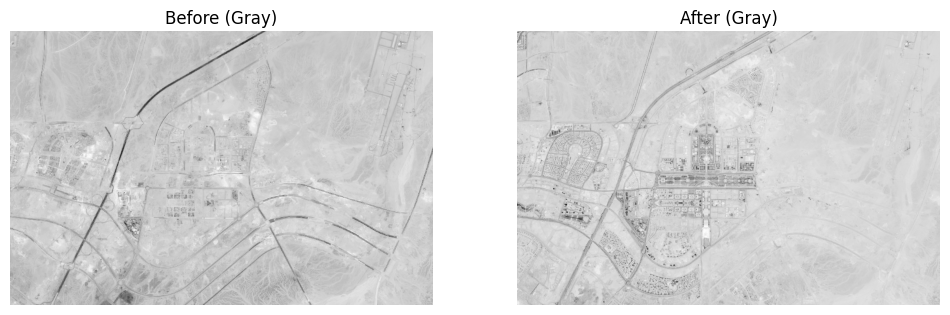

In [6]:
before_gray = cv2.cvtColor(before, cv2.COLOR_RGB2GRAY)
after_gray = cv2.cvtColor(after, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(12,5))

plt.subplot(121)
plt.imshow(before_gray, cmap="gray")
plt.title("Before (Gray)")
plt.axis("off")

plt.subplot(122)
plt.imshow(after_gray, cmap="gray")
plt.title("After (Gray)")
plt.axis("off")

plt.show()

#Histogram Matching

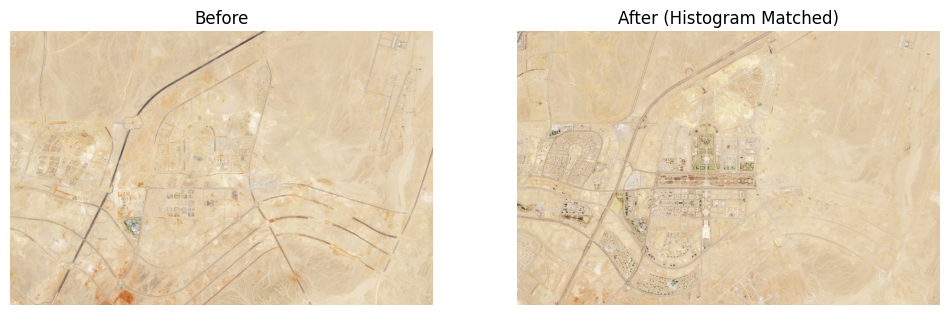

In [7]:
from skimage.exposure import match_histograms

# Match the histogram of the after image to the before image
after_matched = match_histograms(after, before, channel_axis=-1)

# Convert to uint8
after_matched = np.clip(after_matched, 0, 255).astype(np.uint8)

# Convert both images to grayscale
before_gray = cv2.cvtColor(before, cv2.COLOR_RGB2GRAY)
after_gray = cv2.cvtColor(after_matched, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(12,5))

plt.subplot(121)
plt.imshow(before)
plt.title("Before")
plt.axis("off")

plt.subplot(122)
plt.imshow(after_matched)
plt.title("After (Histogram Matched)")
plt.axis("off")

plt.show()

#Gaussian Blur

In [8]:
before_blur = cv2.GaussianBlur(before_gray, (5,5), 0)
after_blur = cv2.GaussianBlur(after_gray, (5,5), 0)

print("Gaussian Blur Applied Successfully.")

Gaussian Blur Applied Successfully.


#Image Difference

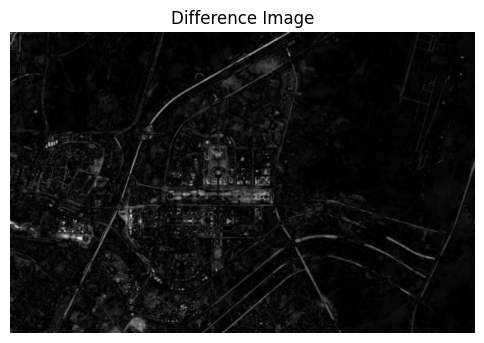

In [9]:
difference = cv2.absdiff(before_blur, after_blur)

plt.figure(figsize=(6,6))
plt.imshow(difference, cmap="gray")
plt.title("Difference Image")
plt.axis("off")
plt.show()

#Otsu Thresholding

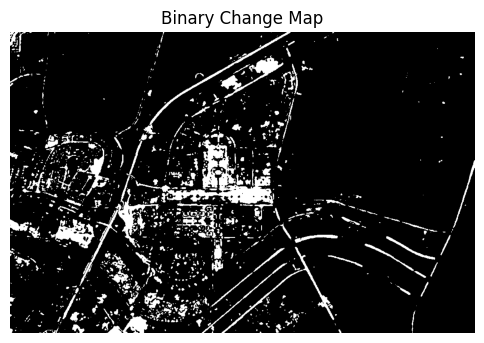

In [10]:
_, binary = cv2.threshold(
    difference,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(6,6))
plt.imshow(binary, cmap="gray")
plt.title("Binary Change Map")
plt.axis("off")
plt.show()

#Morphological Filtering

In [11]:
kernel = np.ones((5,5), np.uint8)

binary = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)

binary = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel)

print("Morphological Filtering Completed.")

Morphological Filtering Completed.


#Remove Small Objects

In [12]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)

min_area = 50

clean = np.zeros_like(binary)

for i in range(1, num_labels):
    if stats[i, cv2.CC_STAT_AREA] >= min_area:
        clean[labels == i] = 255

binary = clean

print("Small Objects Removed.")

Small Objects Removed.


#Calculate Changed Area

In [13]:
changed_pixels = np.sum(binary > 0)

total_pixels = binary.size

percentage = (changed_pixels / total_pixels) * 100

print("="*40)
print(f"Changed Pixels : {changed_pixels}")
print(f"Total Pixels   : {total_pixels}")
print(f"Changed Area   : {percentage:.2f}%")
print("="*40)

Changed Pixels : 31509
Total Pixels   : 695827
Changed Area   : 4.53%


#Generate Overlay

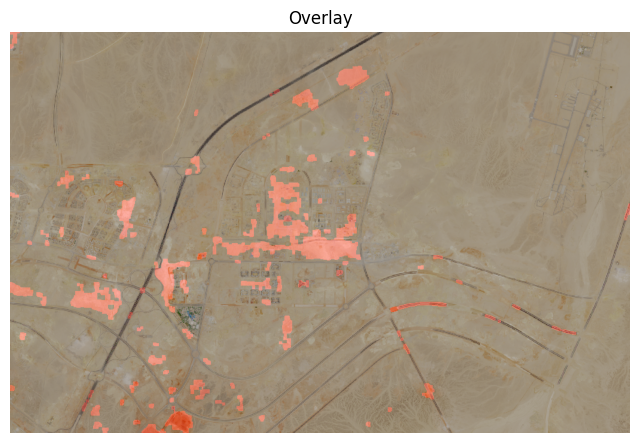

In [14]:

mask = np.zeros_like(before)
mask[:, :, 0] = binary

overlay = cv2.addWeighted(
    before,
    0.7,
    mask,
    0.3,
    0
)

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")
plt.show()

#Draw Contours

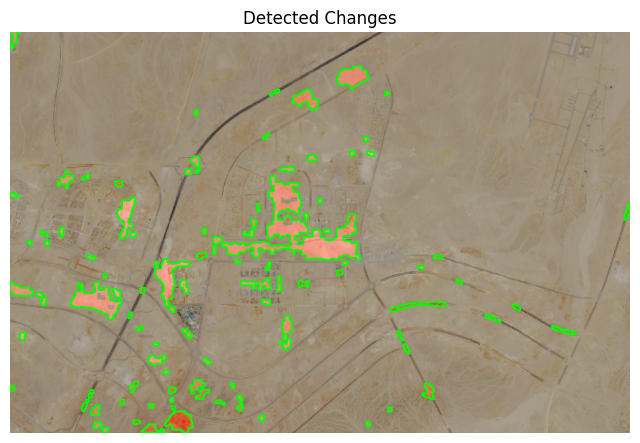

In [15]:
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

result = overlay.copy()

cv2.drawContours(
    result,
    contours,
    -1,
    (0,255,0),
    2
)

plt.figure(figsize=(8,8))
plt.imshow(result)
plt.title("Detected Changes")
plt.axis("off")
plt.show()

#Save Results

In [16]:
os.makedirs("output", exist_ok=True)

plt.imsave("output/before.png", before)


plt.imsave("output/after.png", after_matched)

plt.imsave(
    "output/difference.png",
    difference,
    cmap="gray"
)

plt.imsave(
    "output/binary_change.png",
    binary,
    cmap="gray"
)

plt.imsave(
    "output/overlay.png",
    result
)

print("All Images Saved Successfully.")

All Images Saved Successfully.


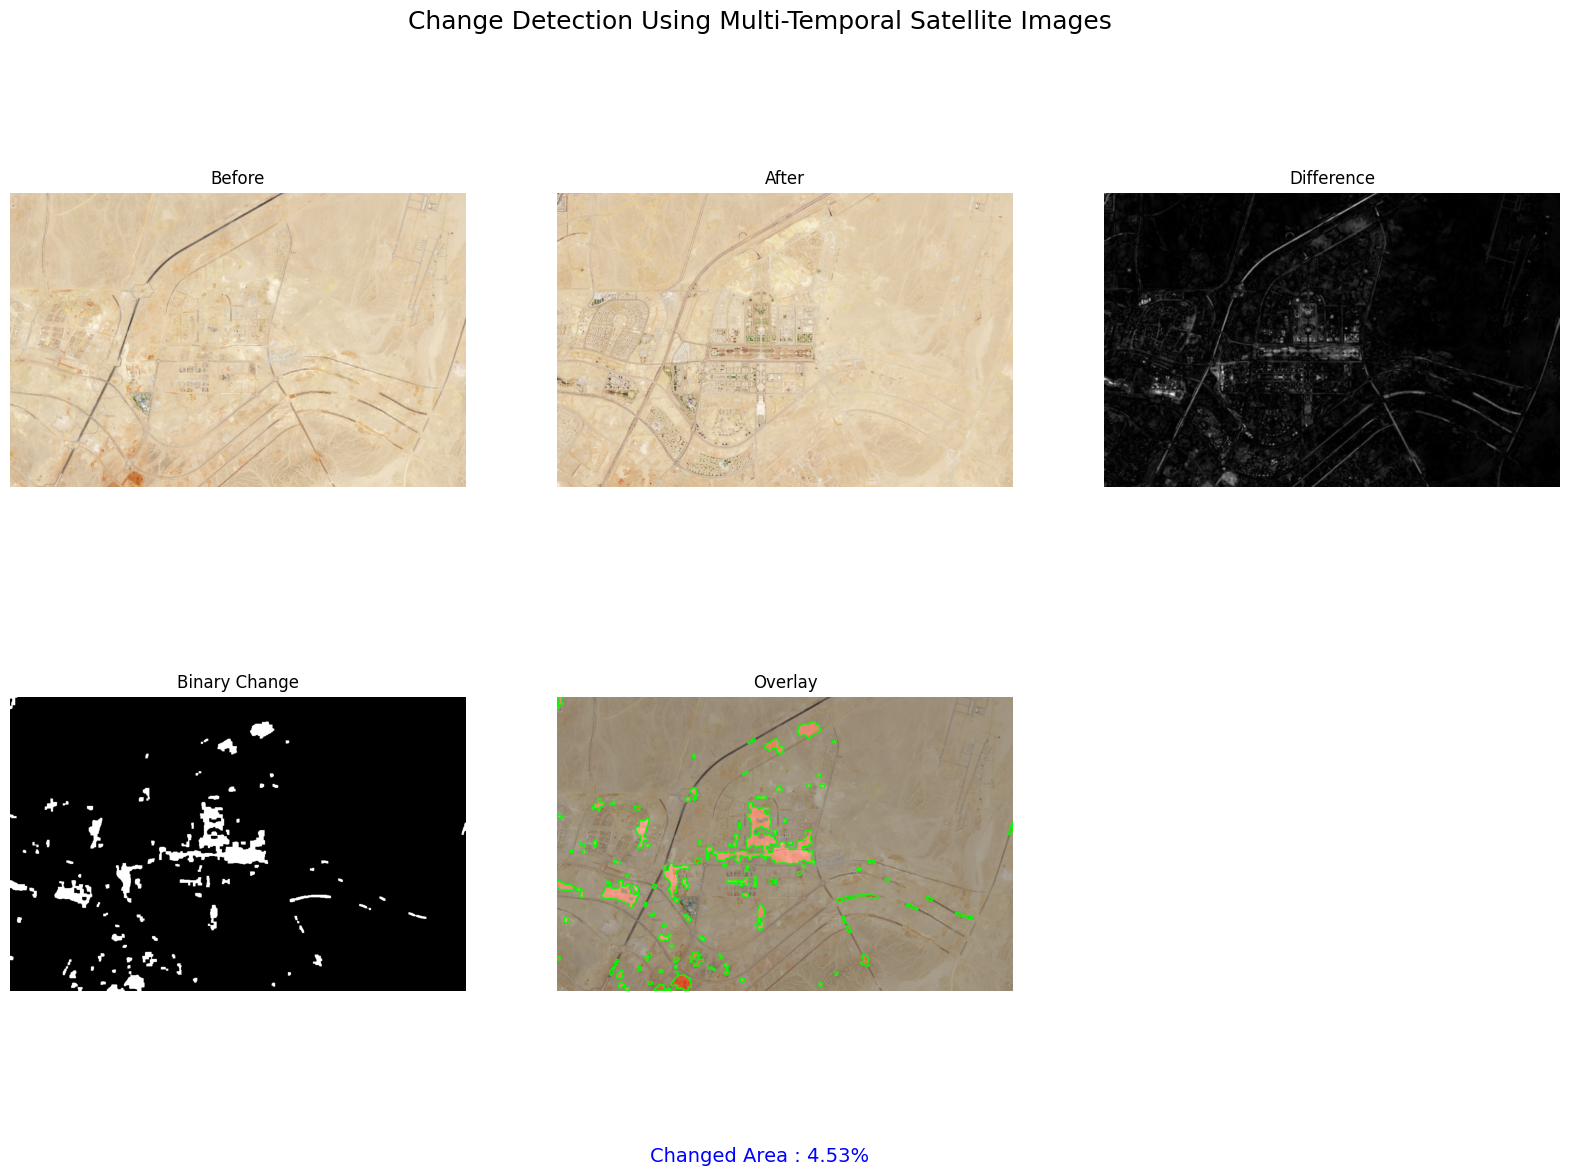

In [17]:
plt.figure(figsize=(20,12))

plt.subplot(231)
plt.imshow(before)
plt.title("Before")
plt.axis("off")

plt.subplot(232)
plt.imshow(after_matched)
plt.title("After")
plt.axis("off")

plt.subplot(233)
plt.imshow(difference, cmap="gray")
plt.title("Difference")
plt.axis("off")

plt.subplot(234)
plt.imshow(binary, cmap="gray")
plt.title("Binary Change")
plt.axis("off")

plt.subplot(235)
plt.imshow(result)
plt.title("Overlay")
plt.axis("off")

plt.suptitle(
    "Change Detection Using Multi-Temporal Satellite Images",
    fontsize=18
)

plt.figtext(
    0.5,
    0.02,
    f"Changed Area : {percentage:.2f}%",
    ha="center",
    fontsize=14,
    color="blue"
)

plt.show()